In [15]:
import pandas as pd

In [16]:
df= pd.read_csv('netflix_titles.csv')

In [17]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [18]:
print(df.isnull().sum)

<bound method DataFrame.sum of       show_id   type  title  director   cast  country  date_added  \
0       False  False  False     False   True    False       False   
1       False  False  False      True  False    False       False   
2       False  False  False     False  False     True       False   
3       False  False  False      True   True     True       False   
4       False  False  False      True  False    False       False   
...       ...    ...    ...       ...    ...      ...         ...   
8802    False  False  False     False  False    False       False   
8803    False  False  False      True   True     True       False   
8804    False  False  False     False  False    False       False   
8805    False  False  False     False  False    False       False   
8806    False  False  False     False  False    False       False   

      release_year  rating  duration  listed_in  description  
0            False   False     False      False        False  
1            F

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
print(df.duplicated().sum())

0


In [21]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [22]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")


In [23]:
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [24]:
print(df.duration)

0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: str


In [ ]:
df.dropna(subset=["date_added"], inplace=True)

TypeError: to_datetime() got an unexpected keyword argument 'infer_datetime_format'

In [27]:
text_columns = [
    "type",
    "title",
    "director",
    "cast",
    "country",
    "rating",
    "listed_in"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()


In [30]:
# Remove leading and trailing spaces
df["date_added"] = df["date_added"].str.strip()

# Convert to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [32]:
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(" ", "_"))

In [33]:
print("\nData Types:")
print(df.dtypes)


Data Types:
show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object


In [34]:
print("\nRemaining Missing Values:")
print(df.isnull().sum())


Remaining Missing Values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [35]:
print("\nCleaned Dataset Shape:", df.shape)


Cleaned Dataset Shape: (8797, 12)


In [37]:
df.to_csv("netflix_titles_cleaned.csv", index=False)
print("\nCleaning Completed Successfully!")
print("Clean dataset saved as 'netflix_titles_cleaned.csv'")


Cleaning Completed Successfully!
Clean dataset saved as 'netflix_titles_cleaned.csv'


In [39]:
original_df = pd.read_csv("netflix_titles.csv")

summary = pd.DataFrame({
    "Metric": [
        "Rows Before",
        "Rows After",
        "Columns",
        "Duplicate Rows",
        "Missing Values Before",
        "Missing Values After"
    ],
    "Value": [
        original_df.shape[0],
        df.shape[0],
        df.shape[1],
        original_df.duplicated().sum(),
        original_df.isnull().sum().sum(),
        df.isnull().sum().sum()
    ]
})

print(summary)

                  Metric  Value
0            Rows Before   8807
1             Rows After   8797
2                Columns     12
3         Duplicate Rows      0
4  Missing Values Before   4307
5   Missing Values After      0


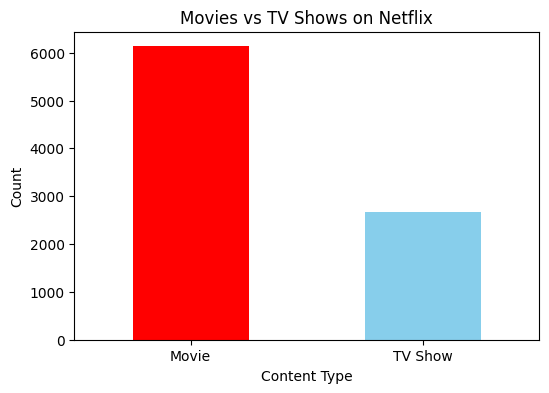

In [46]:
import matplotlib.pyplot as plt

type_counts = df["type"].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind="bar", color=["red", "skyblue"])

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.savefig("charts/movies_vs_tvshows.png", dpi=300, bbox_inches="tight")
plt.show()

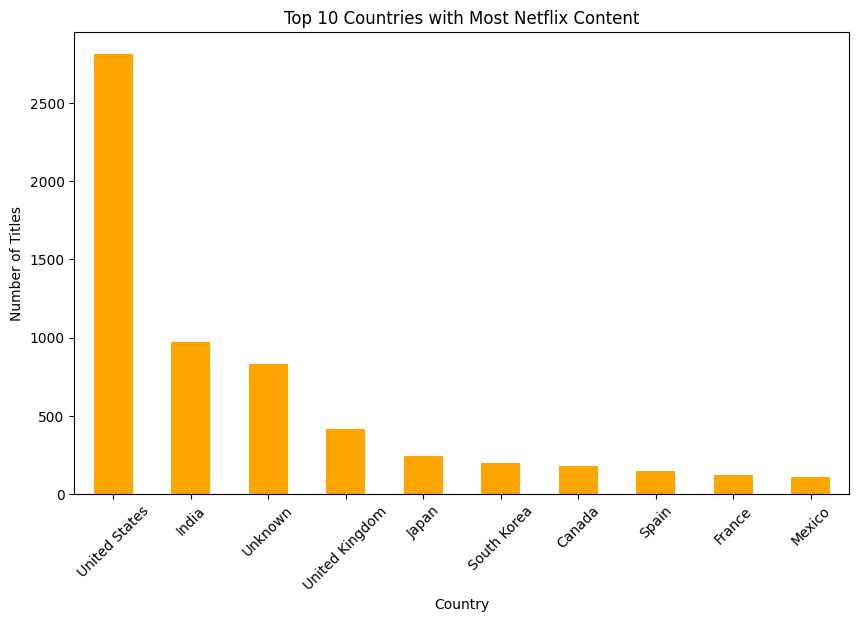

In [47]:
plt.figure(figsize=(10,6))

df["country"].value_counts().head(10).plot(
    kind="bar",
    color="orange"
)

plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.savefig("charts/top 10 countries content wise.png", dpi=300, bbox_inches="tight")

plt.show()

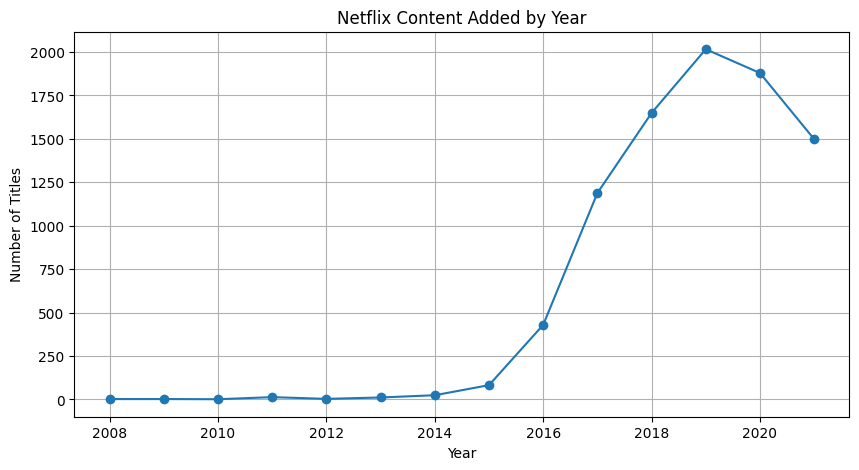

In [48]:
df["year_added"] = df["date_added"].dt.year

plt.figure(figsize=(10,5))

df["year_added"].value_counts().sort_index().plot(
    kind="line",
    marker="o"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.savefig("charts/content by year .png", dpi=300, bbox_inches="tight")

plt.show()

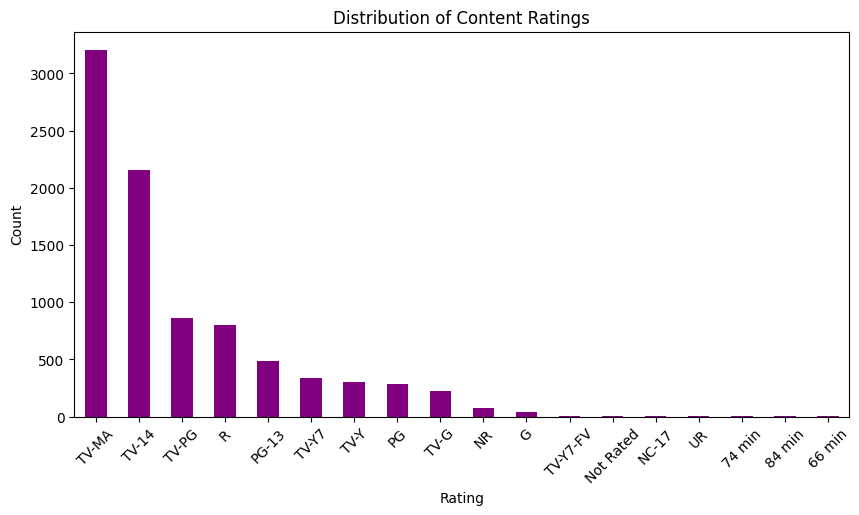

In [49]:
plt.figure(figsize=(10,5))

df["rating"].value_counts().plot(
    kind="bar",
    color="purple"
)

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("charts/distribution of content ratings.png", dpi=300, bbox_inches="tight")

plt.show()

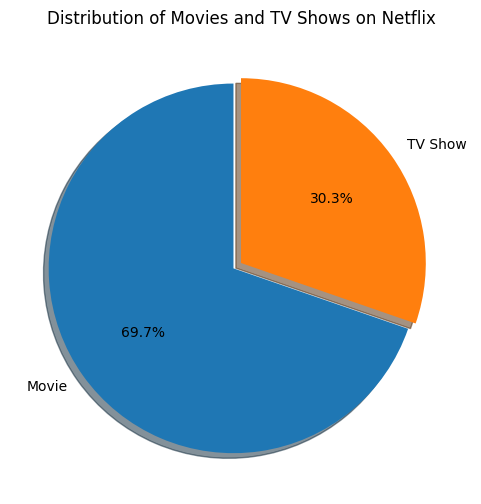

In [50]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0),
    shadow=True
)

plt.title("Distribution of Movies and TV Shows on Netflix")

plt.savefig("charts/pie_chart.png", dpi=300, bbox_inches="tight")

plt.show()

## Conclusion

The Netflix dataset was successfully cleaned by handling missing values, removing duplicates, standardizing text fields, converting dates into a consistent format, and validating data types. The cleaned dataset was further explored using visualizations, providing insights into content distribution, top-producing countries, release trends, genres, and ratings. This prepared dataset is suitable for further data analysis and machine learning tasks.